In [23]:
import pandas as pd
import numpy as np

In [24]:
data = {
    "Student_ID": [1,2,3,4,5,6,7,8,9,10],
    "Name": ["A","B","C",np.nan,"E",np.nan,"G","H","I","J"],
    "Gender": ["M","F","F","M","F",np.nan,"F","M","F","M"],
    "Math_Score": [85, 90, np.nan, 40, 95, 200, 88, 76, np.nan, 65],
    "Science_Score": [78, 85, 82, np.nan, 91, 89, 300, 72, 80, 60],
    "Attendance (%)": [95, 88, 92, 85, np.nan, 110, 87, 90, 93, 85],
    "Study_Hours": [2, 3, 4, 1, 5, 10, 3, 2, 4, np.nan]
}

In [25]:
df = pd.DataFrame(data)
df.head()

,Student_ID,Name,Gender,Math_Score,Science_Score,Attendance (%),Study_Hours
0,1,A,M,85.0,78.0,95.0,2.0
1,2,B,F,90.0,85.0,88.0,3.0
2,3,C,F,NaN,82.0,92.0,4.0
3,4,NaN,M,40.0,NaN,85.0,1.0
4,5,E,F,95.0,91.0,NaN,5.0


In [26]:
q1 = df['Math_Score'].quantile(0.25)
q3 = df['Math_Score'].quantile(0.75)
iqr = q3 - q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

df['Math_Score'] = df['Math_Score'].clip(lower,upper)

In [27]:
df["Math_Score"] = df["Math_Score"].fillna(df["Math_Score"].mean())
df["Science_Score"] = df["Science_Score"].fillna(df["Science_Score"].mean())
df["Attendance (%)"] = df["Attendance (%)"].fillna(df["Attendance (%)"].mean())
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mean())
df["Name"] = df["Name"].fillna(df["Name"].mode()[0])
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])


In [28]:
df.isnull().sum()

Student_ID        0
Name              0
Gender            0
Math_Score        0
Science_Score     0
Attendance (%)    0
Study_Hours       0
dtype: int64

In [29]:
df["Attendance (%)"] = df["Attendance (%)"].clip(0, 100)

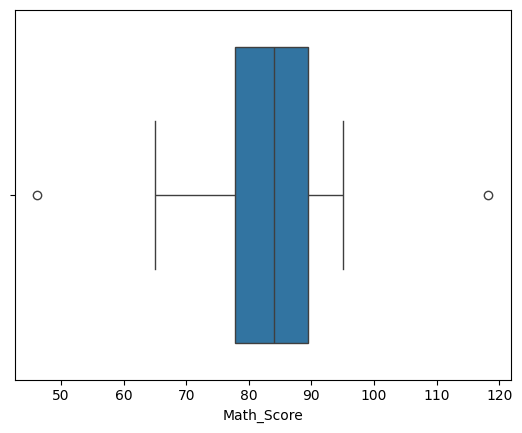

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.boxplot(x=df['Math_Score'])
plt.show()

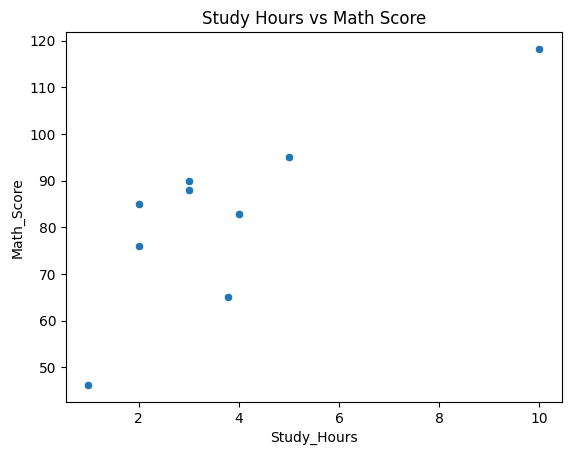

In [31]:
sns.scatterplot(x='Study_Hours', y='Math_Score', data=df)
plt.title('Study Hours vs Math Score')
plt.show()

In [32]:
df['Study_Hours'] = np.log(df['Study_Hours'])

In [35]:
from sklearn.preprocessing import MinMaxScaler

scl = MinMaxScaler()
df['MathNorm'] = scl.fit_transform(df[['Math_Score']])

In [36]:
df.head(10)

,Student_ID,Name,Gender,Math_Score,Science_Score,Attendance (%),Study_Hours,MathNorm
0,1,A,M,85.0000,78.000000,95.000000,0.693147,0.538194
1,2,B,F,90.0000,85.000000,88.000000,1.098612,0.607639
2,3,C,F,82.9375,82.000000,92.000000,1.386294,0.509549
3,4,A,M,46.2500,104.111111,85.000000,0.000000,0.000000
4,5,E,F,95.0000,91.000000,91.666667,1.609438,0.677083
5,6,A,F,118.2500,89.000000,100.000000,2.302585,1.000000
6,7,G,F,88.0000,300.000000,87.000000,1.098612,0.579861
7,8,H,M,76.0000,72.000000,90.000000,0.693147,0.413194
8,9,I,F,82.9375,80.000000,93.000000,1.386294,0.509549
9,10,J,M,65.0000,60.000000,85.000000,1.329136,0.260417
